In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
df=pd.read_csv('C:/Users/IT/Downloads/Heart_data.csv')
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level,Recommendation
0,63,1,66,160,83,160.0,1.80,0.012,negative,Moderate,Monitor closely and consult doctor
1,20,1,94,98,46,296.0,6.75,1.060,positive,High,Immediate medical attention
2,56,1,64,160,77,270.0,1.99,0.003,negative,Moderate,Monitor closely and consult doctor
3,66,1,70,120,55,270.0,13.87,0.122,positive,High,Immediate medical attention
4,54,1,64,112,65,300.0,1.08,0.003,negative,Moderate,Monitor closely and consult doctor


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
 9   Risk_Level                1319 non-null   object 
 10  Recommendation            1319 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 113.5+ KB


In [4]:
np.ptp(df.iloc[:,:-3],axis=0)

Age                           89.000
Gender                         1.000
Heart rate                  1091.000
Systolic blood pressure      181.000
Diastolic blood pressure     116.000
Blood sugar                  506.000
CK-MB                        299.679
Troponin                      10.299
dtype: float64

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier


In [6]:
X=df.iloc[:,:-3]
Y=df.iloc[:,-3]

### Encoding the category and scaler

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
lenc=LabelEncoder()
Y=lenc.fit_transform(Y)


### Splitting the data

In [8]:
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=55)


In [9]:
xtrain=xtrain.reset_index(drop=True)
xtest=xtest.reset_index(drop=True)

In [10]:
scaler=StandardScaler()
xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.transform(xtest)

### Models

In [11]:
knn=KNeighborsClassifier()
knn.fit(xtrain_scaled,ytrain)
ypred=knn.predict(xtest_scaled)
knn_report=classification_report(ytest,ypred,output_dict=True)
print(knn_report)

{'0': {'precision': 0.6161616161616161, 'recall': 0.5865384615384616, 'f1-score': 0.6009852216748769, 'support': 104.0}, '1': {'precision': 0.7393939393939394, 'recall': 0.7625, 'f1-score': 0.7507692307692307, 'support': 160.0}, 'accuracy': 0.6931818181818182, 'macro avg': {'precision': 0.6777777777777778, 'recall': 0.6745192307692307, 'f1-score': 0.6758772262220538, 'support': 264.0}, 'weighted avg': {'precision': 0.6908478726660545, 'recall': 0.6931818181818182, 'f1-score': 0.6917634090047883, 'support': 264.0}}


In [12]:
svc=SVC(probability=True,random_state=98)
svc.fit(xtrain_scaled,ytrain)
ypred=svc.predict(xtest_scaled)
svc_report=classification_report(ytest,ypred,output_dict=True)
print(svc_report)

{'0': {'precision': 0.7272727272727273, 'recall': 0.6153846153846154, 'f1-score': 0.6666666666666666, 'support': 104.0}, '1': {'precision': 0.7727272727272727, 'recall': 0.85, 'f1-score': 0.8095238095238095, 'support': 160.0}, 'accuracy': 0.7575757575757576, 'macro avg': {'precision': 0.75, 'recall': 0.7326923076923078, 'f1-score': 0.7380952380952381, 'support': 264.0}, 'weighted avg': {'precision': 0.7548209366391184, 'recall': 0.7575757575757576, 'f1-score': 0.7532467532467532, 'support': 264.0}}


In [13]:
gbc=GradientBoostingClassifier()
gbc.fit(xtrain_scaled,ytrain)
ypred=gbc.predict(xtest_scaled)
gbc_report=classification_report(ytest,ypred,output_dict=True)
print(gbc_report)

{'0': {'precision': 0.9809523809523809, 'recall': 0.9903846153846154, 'f1-score': 0.9856459330143541, 'support': 104.0}, '1': {'precision': 0.9937106918238994, 'recall': 0.9875, 'f1-score': 0.9905956112852664, 'support': 160.0}, 'accuracy': 0.9886363636363636, 'macro avg': {'precision': 0.9873315363881401, 'recall': 0.9889423076923077, 'f1-score': 0.9881207721498102, 'support': 264.0}, 'weighted avg': {'precision': 0.988684690571483, 'recall': 0.9886363636363636, 'f1-score': 0.9886457380270283, 'support': 264.0}}


In [14]:
lst=[knn_report,svc_report,gbc_report]
models=['KNN','SVM','Gradboost']
positive_metrics={}
negative_metrics={}
for i,j in enumerate(lst):
    pos={'Precision':j['1']['precision'],
         'Recall':j['1']['recall'],
         'F1 score':j['1']['f1-score'],
         'Accuracy':j['accuracy']}
    neg={'Precision':j['0']['precision'],
    'Recall':j['0']['recall'],
    'F1 score':j['0']['f1-score'],
    'Accuracy':j['accuracy']}
    positive_metrics[models[i]]=pos
    negative_metrics[models[i]]=neg


In [15]:
positive_metrics

{'KNN': {'Precision': 0.7393939393939394,
  'Recall': 0.7625,
  'F1 score': 0.7507692307692307,
  'Accuracy': 0.6931818181818182},
 'SVM': {'Precision': 0.7727272727272727,
  'Recall': 0.85,
  'F1 score': 0.8095238095238095,
  'Accuracy': 0.7575757575757576},
 'Gradboost': {'Precision': 0.9937106918238994,
  'Recall': 0.9875,
  'F1 score': 0.9905956112852664,
  'Accuracy': 0.9886363636363636}}

In [16]:
pos_df=pd.DataFrame(positive_metrics)
pos_df

,KNN,SVM,Gradboost
Precision,0.739394,0.772727,0.993711
Recall,0.762500,0.850000,0.987500
F1 score,0.750769,0.809524,0.990596
Accuracy,0.693182,0.757576,0.988636


In [17]:
neg_df=pd.DataFrame(negative_metrics)
neg_df

,KNN,SVM,Gradboost
Precision,0.616162,0.727273,0.980952
Recall,0.586538,0.615385,0.990385
F1 score,0.600985,0.666667,0.985646
Accuracy,0.693182,0.757576,0.988636


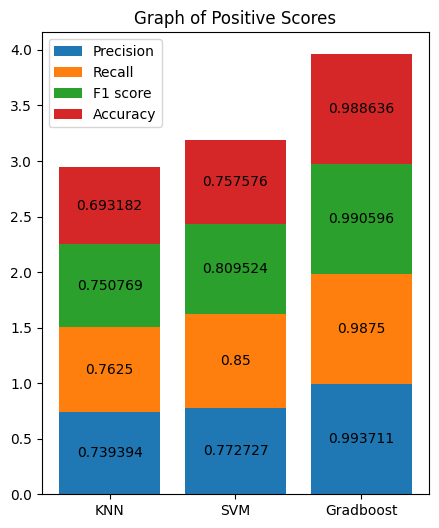

In [18]:
fig,ax=plt.subplots(figsize=(5,6))
bottom=np.zeros(3)
for i,j in enumerate(pos_df.index):
    bar=ax.bar(pos_df.columns,pos_df.loc[j,:],label=j,bottom=bottom)
    bottom+=pos_df.loc[j,:]
    ax.bar_label(bar,label_type='center')
ax.set_title('Graph of Positive Scores')
ax.legend(loc='upper left')
plt.savefig('D:/DS/Positive metrics',bbox_inches='tight')

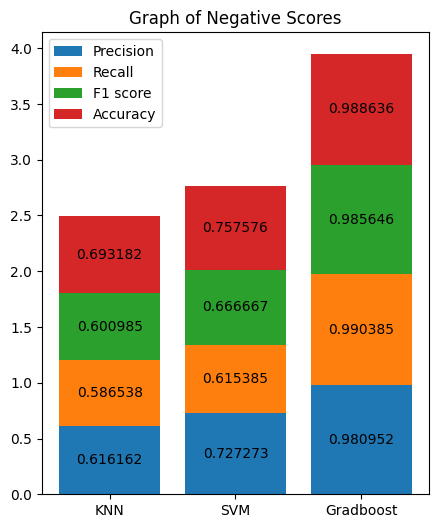

In [19]:
fig,ax=plt.subplots(figsize=(5,6))
bottom=np.zeros(3)
for i,j in enumerate(neg_df.index):
    bar=ax.bar(neg_df.columns,neg_df.loc[j,:],label=j,bottom=bottom)
    bottom+=neg_df.loc[j,:]
    ax.bar_label(bar,label_type='center')
ax.set_title('Graph of Negative Scores')
ax.legend(loc='upper left')
#plt.savefig('D:/DS/Negative metrics',bbox_inches='tight')